In [2]:
import cv2
import yaml
import sys
import numpy as np
import matplotlib.pyplot as plt

## PGM to PNG

In [ ]:
# 지도 이미지 로드
pgm_img = cv2.imread('/home/addinedu/Downloads/clean_map2.pgm', cv2.IMREAD_GRAYSCALE)
# PNG로 저장
cv2.imwrite('/home/addinedu/Downloads/clean_map2.png', pgm_img)

True

## PNG to IMG

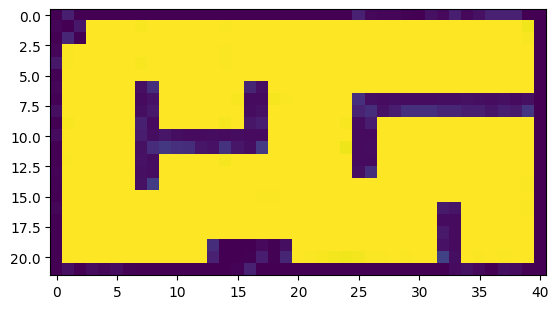

In [37]:
map_img = cv2.imread('/home/addinedu/Downloads/clean_map2.png', cv2.COLOR_BGR2GRAY)
plt.imshow(map_img)

## MAP to ARRAY

In [45]:
def image_Grid_for_map(h, w, image_path):
    """
    주어진 이미지 경로의 PNG 이미지를 읽어와 h x w 크기의 그리드로 분할하고,
    각 그리드 셀에서 검은색(<=210) 픽셀 비율이 높으면 1, 흰색(>210) 비율이 높으면 0으로 표현하는 맵을 생성합니다.

    Args:
        h (int): 그리드의 세로 분할 개수.
        w (int): 그리드의 가로 분할 개수.
        image_path (str): PNG 이미지 파일의 경로.

    Returns:
        tuple: (map_cost, cell_height, cell_width)
               map_cost (list[list[int]]): 생성된 비용 맵 (0: 흰색 비율 높음, 1: 검은색 비율 높음).
               cell_height (int): 각 그리드 셀의 높이 (픽셀 단위).
               cell_width (int): 각 그리드 셀의 너비 (픽셀 단위).
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Error: Could not read image at {image_path}")
        return [], 0, 0

    img_height, img_width = img.shape
    grid_size = (h, w)  # 세로, 가로

    # 그리드 영역 크기 계산
    cell_height = img_height // grid_size[0]
    cell_width = img_width // grid_size[1]

    map_cost = []
    map_col = []

    # 각각의 그리드 영역에서 검은색/흰색 픽셀 비율 계산
    for i in range(grid_size[0]):
        map_col = []
        for j in range(grid_size[1]):
            # 그리드 영역의 범위를 지정
            cell_top = i * cell_height
            cell_left = j * cell_width
            cell_bottom = cell_top + cell_height
            cell_right = cell_left + cell_width

            # 마지막 행/열의 경우 이미지 경계까지 포함
            if i == h - 1:
                cell_bottom = img_height
            if j == w - 1:
                cell_right = img_width

            # 현재 그리드 셀의 픽셀 데이터 추출
            cell = img[cell_top:cell_bottom, cell_left:cell_right]
            wall_pixels = np.sum(cell <= 210)
            road_pixels = cell.size - wall_pixels

            # 검은색(벽) 픽셀 수가 흰색(도로) 픽셀 수보다 많으면 1 (벽), 아니면 0 (도로)
            if wall_pixels > road_pixels:
                map_col.append(1)
            else:
                map_col.append(0)
        map_cost.append(map_col)
    return map_cost, cell_height, cell_width

if __name__ == "__main__":
    image_path = '/home/addinedu/Downloads/clean_map2.png'  # 실제 이미지 파일 경로로 변경해주세요.
    grid_height = 22  # 원하는 세로 그리드 셀 수
    grid_width = 41   # 원하는 가로 그리드 셀 수

    map_data, cell_h, cell_w = image_Grid_for_map(grid_height, grid_width, image_path)

    if map_data:
        print(f"{grid_height} {grid_width}")  # 이미지와 같이 그리드 크기 먼저 출력
        for row in map_data:
            print(row)
        # 필요하다면 셀 크기 정보도 출력
        # print(f"각 그리드 셀 높이: {cell_h} 픽셀")
        # print(f"각 그리드 셀 너비: {cell_w} 픽셀")
    else:
        print("이미지 로드 실패")

22 41
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
[1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
[1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1

In [1]:
import cv2
import numpy as np

def image_Grid_for_map(h, w, image_path):
    """
    주어진 이미지 경로의 PNG 이미지를 읽어와 h x w 크기의 그리드로 분할하고,
    각 그리드 셀에서 검은색(<=210) 픽셀 비율이 높으면 1, 흰색(>210) 비율이 높으면 0으로 표현하는 맵을 생성합니다.

    Args:
        h (int): 그리드의 세로 분할 개수.
        w (int): 그리드의 가로 분할 개수.
        image_path (str): PNG 이미지 파일의 경로.

    Returns:
        tuple: (map_cost, cell_height, cell_width)
               map_cost (list[list[int]]): 생성된 비용 맵 (0: 흰색 비율 높음, 1: 검은색 비율 높음).
               cell_height (int): 각 그리드 셀의 높이 (픽셀 단위).
               cell_width (int): 각 그리드 셀의 너비 (픽셀 단위).
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Error: Could not read image at {image_path}")
        return [], 0, 0

    img_height, img_width = img.shape
    grid_size = (h, w)  # 세로, 가로

    # 그리드 영역 크기 계산
    cell_height = img_height // grid_size[0]
    cell_width = img_width // grid_size[1]

    map_cost = []
    map_col = []

    # 각각의 그리드 영역에서 검은색/흰색 픽셀 비율 계산
    for i in range(grid_size[0]):
        map_col = []
        for j in range(grid_size[1]):
            # 그리드 영역의 범위를 지정
            cell_top = i * cell_height
            cell_left = j * cell_width
            cell_bottom = cell_top + cell_height
            cell_right = cell_left + cell_width

            # 마지막 행/열의 경우 이미지 경계까지 포함
            if i == h - 1:
                cell_bottom = img_height
            if j == w - 1:
                cell_right = img_width

            # 현재 그리드 셀의 픽셀 데이터 추출
            cell = img[cell_top:cell_bottom, cell_left:cell_right]
            wall_pixels = np.sum(cell <= 210)
            road_pixels = cell.size - wall_pixels

            # 검은색(벽) 픽셀 수가 흰색(도로) 픽셀 수보다 많으면 1 (벽), 아니면 0 (도로)
            if wall_pixels > road_pixels:
                map_col.append(1)
            else:
                map_col.append(0)
        map_cost.append(map_col)
    return map_cost, cell_height, cell_width

# --- 맵 생성 ---
image_path = '/home/addinedu/Downloads/clean_map2.png'  # 실제 이미지 파일 경로로 변경해주세요.
grid_height = 22  # 원하는 세로 그리드 셀 수
grid_width = 41   # 원하는 가로 그리드 셀 수

map_data, cell_h, cell_w = image_Grid_for_map(grid_height, grid_width, image_path)

In [3]:
if map_data:
    print("생성된 맵:")
    print(f"{grid_height} {grid_width}")  # 이미지와 같이 그리드 크기 먼저 출력
    for row in map_data:
        print(row)
    # 필요하다면 셀 크기 정보도 출력
    # print(f"각 그리드 셀 높이: {cell_h} 픽셀")
    # print(f"각 그리드 셀 너비: {cell_w} 픽셀")
else:
    print("맵 데이터가 없습니다. 맵 생성 파트를 먼저 실행해주세요.")

생성된 맵:
22 41
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
[1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
[1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

## A* 알고리즘으로 경로 생성

In [62]:
class Astar:
    def __init__(self, parent=None, position=None):
        self.parent = parent
        self.position = position

        self.g = 0
        self.h = 0
        self.f = 0

    def __eq__(self, other):
        return self.position == other.position

    def heuristic(self, node, goal, D=1, D2=2 ** 0.5):  # Diagonal Distance
        dx = abs(node.position[0] - goal.position[0])
        dy = abs(node.position[1] - goal.position[1])
        return D * (dx + dy)


    def aStar(self, maze, start, end):
        # startNode와 endNode 초기화
        startNode = Astar(None, start)
        endNode = Astar(None, end)

        # openList, closedList 초기화
        openList = []
        closedList = []

        # openList에 시작 노드 추가
        openList.append(startNode)

        # endNode를 찾을 때까지 실행
        while openList:

            # 현재 노드 지정
            currentNode = openList[0]
            currentIdx = 0

            # 이미 같은 노드가 openList에 있고, f 값이 더 크면
            # currentNode를 openList안에 있는 값으로 교체
            for index, item in enumerate(openList):
                if item.f < currentNode.f:
                    currentNode = item
                    currentIdx = index

            # openList에서 제거하고 closedList에 추가
            openList.pop(currentIdx)
            closedList.append(currentNode)

            # 현재 노드가 목적지면 current.position 추가하고
            # current의 부모로 이동
            if currentNode == endNode:
                path = []
                current = currentNode
                while current is not None:
                    path.append(current.position)
                    current = current.parent
                return path[::-1]  # reverse

            children = []
            # 인접한 xy좌표 전부
            for newPosition in [(0, -1), (0, 1), (-1, 0), (1, 0)]:

                # 노드 위치 업데이트
                nodePosition = (
                    currentNode.position[0] + newPosition[0],  # X
                    currentNode.position[1] + newPosition[1])  # Y

                # 미로 maze index 범위 안에 있어야함
                within_range_criteria = [
                    nodePosition[0] > (len(maze) - 1),
                    nodePosition[0] < 0,
                    nodePosition[1] > (len(maze[len(maze) - 1]) - 1),
                    nodePosition[1] < 0,
                ]

                if any(within_range_criteria):  # 하나라도 true면 범위 밖임
                    continue

                # 장애물이 있으면 다른 위치 불러오기
                if maze[nodePosition[0]][nodePosition[1]] != 0:  # 2번 코드는 벽이 1
                    continue

                new_node = Astar(currentNode, nodePosition)
                children.append(new_node)

            # 자식들 모두 loop
            for child in children:

                # 자식이 closedList에 있으면 continue
                if child in closedList:
                    continue

                # f, g, h값 업데이트
                child.g = currentNode.g + 1
                child.h = ((child.position[0] - endNode.position[0]) **
                        2) + ((child.position[1] - endNode.position[1]) ** 2)
                # child.h = heuristic(child, endNode) 다른 휴리스틱
                # print("position:", child.position) 거리 추정 값 보기
                # print("from child to goal:", child.h)

                child.f = child.g + child.h

                # 자식이 openList에 있으고, g값이 더 크면 continue
                if len([openNode for openNode in openList
                        if child == openNode and child.g > openNode.g]) > 0:
                    continue

                openList.append(child)

        return None  # 경로를 찾지 못한 경우 None 반환

    def run(self, maze, start, end):
        path = self.aStar(maze, start, end)
        return path

# --- A* 알고리즘 실행 및 경로 표시 ---
if map_data:

    astar = Astar()
    start_point = (5, 5)  # 시작 좌표 (행, 열) - 예시 값, 실제 맵에 맞게 변경 필요
    end_point = (18, 38)    # 도착 좌표 (행, 열) - 예시 값, 실제 맵에 맞게 변경 필요

    # 시작점과 끝점이 유효한 범위 내에 있고 이동 가능한지 확인
    if 0 <= start_point[0] < grid_height and 0 <= start_point[1] < grid_width and map_data[start_point[0]][start_point[1]] == 0 and \
       0 <= end_point[0] < grid_height and 0 <= end_point[1] < grid_width and map_data[end_point[0]][end_point[1]] == 0:

        path = astar.run(map_data, start_point, end_point)

        if path:
            print("\nA* 알고리즘으로 찾은 경로 좌표:")
            print(path)

            # 경로를 2로 표시한 맵 생성 (원본 맵 복사)
            path_map = [list(row) for row in map_data]
            for row, col in path:
                path_map[row][col] = 2

            print("\n경로가 표시된 맵 (2는 경로):")
            for row in path_map:
                print(row)

        else:
            print("\nA* 알고리즘: 경로를 찾을 수 없습니다.")

    else:
        print("\n시작점 또는 도착점이 유효하지 않거나 벽입니다.")

else:
    print("맵 데이터가 없습니다. 맵 생성 파트를 먼저 실행해주세요.")


A* 알고리즘으로 찾은 경로 좌표:
[(5, 5), (5, 6), (5, 7), (5, 8), (5, 9), (5, 10), (5, 11), (5, 12), (5, 13), (5, 14), (5, 15), (5, 16), (5, 17), (5, 18), (5, 19), (5, 20), (5, 21), (5, 22), (5, 23), (5, 24), (6, 24), (7, 24), (8, 24), (9, 24), (10, 24), (11, 24), (12, 24), (13, 24), (14, 24), (14, 25), (14, 26), (14, 27), (14, 28), (14, 29), (14, 30), (14, 31), (14, 32), (14, 33), (14, 34), (14, 35), (15, 35), (15, 36), (16, 36), (16, 37), (17, 37), (17, 38), (18, 38)]

경로가 표시된 맵 (2는 경로):
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
[1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
[1, 0, 0, 0, 0, 0, 0,